# Half-Life Exit Rule Validation

This notebook compares the original pairs trading rule against a half-life-based maximum holding-period rule.

The original strategy exits a trade when the spread z-score reverts close to 0: $|z_t| < 0.5$

The half-life exit keeps the same z-score exit rule, but also exits a trade if it remains open for more than a fixed multiple of the estimated OU half-life.

The goal is to test whether the half-life based exit improves out-of-sample performance and risk control.

In [2]:
# imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

from src.data import download_prices
from src.pairs_trading import (
    compute_simple_returns,
    rank_pairs_by_correlation,
    compute_rolling_spread,
    run_dynamic_beta_backtest,
    estimate_ou_parameters,
)

## Data

I use the same ETF universe and sample period as the previous notebooks. Daily adjusted close prices are loaded from the local cache when available.

In [4]:
tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLE", "XLV",
    "XLY", "XLP", "XLI", "XLU",
    "TLT", "HYG", "LQD", "GLD",
]

start = "2015-01-01"
end = "2026-01-01"

prices = download_prices(
    tickers=tickers,
    start=start,
    end=end,
)

returns = compute_simple_returns(prices)

print("prices:", prices.shape)
print("returns:", returns.shape)

prices.head()

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
Loading XLK from cache...
Loading XLF from cache...
Loading XLE from cache...
Loading XLV from cache...
Loading XLY from cache...
Loading XLP from cache...
Loading XLI from cache...
Loading XLU from cache...
Loading TLT from cache...
Loading HYG from cache...
Loading LQD from cache...
Loading GLD from cache...
prices: (2766, 15)
returns: (2765, 15)


,SPY,QQQ,IWM,XLK,XLF,XLE,XLV,XLY,XLP,XLI,XLU,TLT,HYG,LQD,GLD
Date,,,,,,,,,,,,,,,
2015-01-02,169.687866,94.561134,102.543121,18.062738,16.217979,25.365137,56.807293,31.573736,35.618256,46.097977,16.406504,92.659241,48.571236,80.124290,114.080002
2015-01-05,166.623337,93.174057,101.172203,17.786995,15.876958,24.315830,56.517605,30.969851,35.367790,45.021183,16.205923,94.114807,48.121277,80.451912,115.800003
2015-01-06,165.053925,91.924744,99.421921,17.572544,15.634314,23.958616,56.327225,30.661303,35.323582,44.466480,16.216291,95.810455,47.936970,80.779549,117.120003
2015-01-07,167.110687,93.109741,100.646263,17.721348,15.798264,24.009644,57.651592,31.146170,35.927650,44.800945,16.375380,95.621239,48.235123,80.886536,116.430000
2015-01-08,170.076004,94.891846,102.353447,18.110880,16.034355,24.548655,58.636589,31.613401,36.472797,45.698257,16.489502,94.354973,48.598339,80.625763,115.940002


## Strategy Settings

The baseline strategy settings come from the earlier parameter sensitivity analysis. 

The half-life exit rule uses the estimated training-period OU half-life to define a maximum holding period.

In [8]:
hedge_window = 252
zscore_window = 120
entry_threshold = 2.0
exit_threshold = 0.5
transaction_cost_bps = 5.0

n_candidate_pairs = 10
n_selected_pairs = 5

half_life_multiplier = 3.0
min_holding_days = 20
max_holding_days_cap = 120

In [10]:
def choose_max_holding_days(
    half_life: float,
    multiplier: float = 3.0,
    min_days: int = 20,
    max_days: int = 120,
) -> int | None:
    """
    Convert an estimated OU half-life into a maximum holding period.

    If the half-life is missing or invalid, return None.
    """
    if half_life is None or np.isnan(half_life):
        return None

    holding_days = int(round(multiplier*half_life))
    holding_days = max(min_days, holding_days)
    holding_days = min(max_days, holding_days)

    return holding_days

In [12]:
def select_directed_pairs(
    prices: pd.DataFrame,
    train_start: str,
    train_end: str,
    n_candidate_pairs: int = 10,
    n_selected_pairs: int = 5,
) -> pd.DataFrame:
    """
    Select directed pairs using training-period information only.

    Candidate pairs are ranked by training return correlation.
    Both regression directions are tested in the training period.
    The top directed pairs are selected by training Sharpe ratio.
    """
    train_prices = prices.loc[train_start:train_end]
    train_returns = compute_simple_returns(train_prices)

    ranked_pairs = rank_pairs_by_correlation(train_returns)
    candidate_pairs = ranked_pairs.head(n_candidate_pairs)

    results = []

    for _, row in candidate_pairs.iterrows():
        ticker_a = row["ticker_1"]
        ticker_b = row["ticker_2"]
        train_correlation = row["correlation"]

        directions = [
            (ticker_a, ticker_b),
            (ticker_b, ticker_a),
        ]

        for ticker_y, ticker_x in directions:
            try:
                metrics = run_dynamic_beta_backtest(
                    prices=prices,
                    ticker_y=ticker_y,
                    ticker_x=ticker_x,
                    hedge_window=hedge_window,
                    zscore_window=zscore_window,
                    entry_threshold=entry_threshold,
                    exit_threshold=exit_threshold,
                    transaction_cost_bps=transaction_cost_bps,
                    evaluation_start=train_start,
                    evaluation_end=train_end,
                    max_holding_days=None,
                )

                metrics["pair"] = f"Y={ticker_y}/X={ticker_x}"
                metrics["ticker_y"] = ticker_y
                metrics["ticker_x"] = ticker_x
                metrics["train_correlation"] = train_correlation

                results.append(metrics)

            except Exception as e:
                print(f"Failed on Y={ticker_y}, X={ticker_x}: {e}")

    results_df = pd.DataFrame(results)

    selected_pairs = (
        results_df
        .sort_values("sharpe_ratio", ascending=False)
        .head(n_selected_pairs)
        .copy()
    )

    return selected_pairs

In [14]:
def estimate_pair_half_life(
    prices: pd.DataFrame,
    ticker_y: str,
    ticker_x: str,
    train_start: str,
    train_end: str,
    hedge_window: int = 252,
) -> float:
    """
    Estimate OU half-life for a pair using the training-period rolling spread.
    """
    train_prices = prices.loc[train_start:train_end]

    rolling_spread_df = compute_rolling_spread(
        prices=train_prices,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
        window=hedge_window,
    )

    spread = rolling_spread_df["spread"]

    ou_params = estimate_ou_parameters(spread)

    return ou_params["ou_half_life"]

In [16]:
def evaluate_selected_pairs(
    prices: pd.DataFrame,
    selected_pairs: pd.DataFrame,
    train_start: str,
    train_end: str,
    test_start: str,
    test_end: str,
    use_half_life_exit: bool = False,
) -> pd.DataFrame:
    """
    Evaluate selected directed pairs out of sample.

    If use_half_life_exit is True, estimate each pair's half-life using
    training data only and use it to set a maximum holding period.
    """
    results = []

    for _, row in selected_pairs.iterrows():
        ticker_y = row["ticker_y"]
        ticker_x = row["ticker_x"]

        if use_half_life_exit:
            half_life = estimate_pair_half_life(
                prices=prices,
                ticker_y=ticker_y,
                ticker_x=ticker_x,
                train_start=train_start,
                train_end=train_end,
                hedge_window=hedge_window,
            )

            max_holding_days = choose_max_holding_days(
                half_life=half_life,
                multiplier=half_life_multiplier,
                min_days=min_holding_days,
                max_days=max_holding_days_cap,
            )
        else:
            half_life = np.nan
            max_holding_days = None

        metrics = run_dynamic_beta_backtest(
            prices=prices,
            ticker_y=ticker_y,
            ticker_x=ticker_x,
            hedge_window=hedge_window,
            zscore_window=zscore_window,
            entry_threshold=entry_threshold,
            exit_threshold=exit_threshold,
            transaction_cost_bps=transaction_cost_bps,
            evaluation_start=test_start,
            evaluation_end=test_end,
            max_holding_days=max_holding_days,
        )

        metrics["pair"] = f"Y={ticker_y}/X={ticker_x}"
        metrics["ticker_y"] = ticker_y
        metrics["ticker_x"] = ticker_x
        metrics["train_correlation"] = row["train_correlation"]
        metrics["train_sharpe"] = row["sharpe_ratio"]
        metrics["half_life"] = half_life
        metrics["max_holding_days"] = max_holding_days
        metrics["exit_rule"] = "half_life" if use_half_life_exit else "original"

        results.append(metrics)

    return pd.DataFrame(results)

In [18]:
result_cols = [
    "exit_rule",
    "pair",
    "ticker_y",
    "ticker_x",
    "train_correlation",
    "train_sharpe",
    "half_life",
    "max_holding_days",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "avg_holding_days",
    "days_in_market_frac",
]

## Train/Test Split

First I compare the two exit rules using a fixed train/test set split.

The training period is used to:
- rank candidate pairs by return correlation
- selected directed pairs by training Sharpe ratio
- estimate OU half-life for the half-life exit rule

The test set is used only for out-of-sample evaluation.

In [21]:
fixed_train_start = "2015-01-01"
fixed_train_end = "2023-12-31"

fixed_test_start = "2024-01-01"
fixed_test_end = "2026-01-01"

In [25]:
fixed_selected_pairs = select_directed_pairs(
    prices=prices,
    train_start=fixed_train_start,
    train_end=fixed_train_end,
    n_candidate_pairs=n_candidate_pairs,
    n_selected_pairs=n_selected_pairs,
)

fixed_selected_pairs[
    [
        "pair",
        "ticker_y",
        "ticker_x",
        "train_correlation",
        "total_return",
        "sharpe_ratio",
        "n_trades",
    ]
].round(4)

,pair,ticker_y,ticker_x,train_correlation,total_return,sharpe_ratio,n_trades
19,Y=XLI/X=IWM,XLI,IWM,0.8597,0.2020,0.6637,27
1,Y=XLK/X=QQQ,XLK,QQQ,0.9763,0.0428,0.3231,28
13,Y=XLI/X=XLF,XLI,XLF,0.8819,0.0742,0.2949,23
2,Y=SPY/X=XLK,SPY,XLK,0.9339,0.0492,0.2389,25
0,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.0231,0.1788,26


In [27]:
fixed_original_results = evaluate_selected_pairs(
    prices=prices,
    selected_pairs=fixed_selected_pairs,
    train_start=fixed_train_start,
    train_end=fixed_train_end,
    test_start=fixed_test_start,
    test_end=fixed_test_end,
    use_half_life_exit=False,
)

fixed_original_results[result_cols].sort_values("sharpe_ratio", ascending=False).round(4)

,exit_rule,pair,ticker_y,ticker_x,train_correlation,train_sharpe,half_life,max_holding_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_trades,win_rate,avg_holding_days,days_in_market_frac
3,original,Y=SPY/X=XLK,SPY,XLK,0.9339,0.2389,NaN,None,0.0815,0.0401,0.0266,1.4919,-0.0163,9,1.0000,14.4444,0.2410
4,original,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.1788,NaN,None,0.0365,0.0181,0.0182,0.9972,-0.0182,9,0.8889,20.7778,0.3546
1,original,Y=XLK/X=QQQ,XLK,QQQ,0.9763,0.3231,NaN,None,0.0364,0.0181,0.0226,0.8067,-0.0248,9,0.7778,19.5556,0.3327
0,original,Y=XLI/X=IWM,XLI,IWM,0.8597,0.6637,NaN,None,0.0141,0.0071,0.0364,0.2117,-0.0452,7,0.8571,22.7143,0.4502
2,original,Y=XLI/X=XLF,XLI,XLF,0.8819,0.2949,NaN,None,0.0047,0.0024,0.0374,0.0820,-0.0549,8,0.7500,23.8750,0.3924


In [28]:
fixed_half_life_results = evaluate_selected_pairs(
    prices=prices,
    selected_pairs=fixed_selected_pairs,
    train_start=fixed_train_start,
    train_end=fixed_train_end,
    test_start=fixed_test_start,
    test_end=fixed_test_end,
    use_half_life_exit=True,
)

fixed_half_life_results[result_cols].sort_values("sharpe_ratio", ascending=False).round(4)

,exit_rule,pair,ticker_y,ticker_x,train_correlation,train_sharpe,half_life,max_holding_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_trades,win_rate,avg_holding_days,days_in_market_frac
3,half_life,Y=SPY/X=XLK,SPY,XLK,0.9339,0.2389,37.3860,112,0.0815,0.0401,0.0266,1.4919,-0.0163,9,1.0000,14.4444,0.2410
4,half_life,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.1788,40.2146,120,0.0365,0.0181,0.0182,0.9972,-0.0182,9,0.8889,20.7778,0.3546
1,half_life,Y=XLK/X=QQQ,XLK,QQQ,0.9763,0.3231,34.5490,104,0.0364,0.0181,0.0226,0.8067,-0.0248,9,0.7778,19.5556,0.3327
0,half_life,Y=XLI/X=IWM,XLI,IWM,0.8597,0.6637,46.7652,120,0.0141,0.0071,0.0364,0.2117,-0.0452,7,0.8571,22.7143,0.4502
2,half_life,Y=XLI/X=XLF,XLI,XLF,0.8819,0.2949,53.2147,120,0.0047,0.0024,0.0374,0.0820,-0.0549,8,0.7500,23.8750,0.3924


In [31]:
fixed_comparison = pd.concat(
    [
        fixed_original_results,
        fixed_half_life_results,
    ],
    ignore_index=True,
)

fixed_comparison[result_cols].sort_values(
    ["pair", "exit_rule"]
).round(4)

,exit_rule,pair,ticker_y,ticker_x,train_correlation,train_sharpe,half_life,max_holding_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_trades,win_rate,avg_holding_days,days_in_market_frac
9,half_life,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.1788,40.2146,120,0.0365,0.0181,0.0182,0.9972,-0.0182,9,0.8889,20.7778,0.3546
4,original,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.1788,NaN,None,0.0365,0.0181,0.0182,0.9972,-0.0182,9,0.8889,20.7778,0.3546
8,half_life,Y=SPY/X=XLK,SPY,XLK,0.9339,0.2389,37.3860,112,0.0815,0.0401,0.0266,1.4919,-0.0163,9,1.0000,14.4444,0.2410
3,original,Y=SPY/X=XLK,SPY,XLK,0.9339,0.2389,NaN,None,0.0815,0.0401,0.0266,1.4919,-0.0163,9,1.0000,14.4444,0.2410
5,half_life,Y=XLI/X=IWM,XLI,IWM,0.8597,0.6637,46.7652,120,0.0141,0.0071,0.0364,0.2117,-0.0452,7,0.8571,22.7143,0.4502
0,original,Y=XLI/X=IWM,XLI,IWM,0.8597,0.6637,NaN,None,0.0141,0.0071,0.0364,0.2117,-0.0452,7,0.8571,22.7143,0.4502
7,half_life,Y=XLI/X=XLF,XLI,XLF,0.8819,0.2949,53.2147,120,0.0047,0.0024,0.0374,0.0820,-0.0549,8,0.7500,23.8750,0.3924
2,original,Y=XLI/X=XLF,XLI,XLF,0.8819,0.2949,NaN,None,0.0047,0.0024,0.0374,0.0820,-0.0549,8,0.7500,23.8750,0.3924
6,half_life,Y=XLK/X=QQQ,XLK,QQQ,0.9763,0.3231,34.5490,104,0.0364,0.0181,0.0226,0.8067,-0.0248,9,0.7778,19.5556,0.3327
1,original,Y=XLK/X=QQQ,XLK,QQQ,0.9763,0.3231,NaN,None,0.0364,0.0181,0.0226,0.8067,-0.0248,9,0.7778,19.5556,0.3327


In [33]:
fixed_pair_comparison = fixed_comparison.pivot_table(
    index="pair",
    columns="exit_rule",
    values=[
        "total_return",
        "sharpe_ratio",
        "max_drawdown",
        "n_trades",
        "avg_holding_days",
        "days_in_market_frac",
    ],
)

fixed_pair_comparison.round(4)

avg_holding_days          days_in_market_frac           \
exit_rule          half_life original           half_life original   
pair                                                                 
Y=QQQ/X=XLK          20.7778  20.7778              0.3546   0.3546   
Y=SPY/X=XLK          14.4444  14.4444              0.2410   0.2410   
Y=XLI/X=IWM          22.7143  22.7143              0.4502   0.4502   
Y=XLI/X=XLF          23.8750  23.8750              0.3924   0.3924   
Y=XLK/X=QQQ          19.5556  19.5556              0.3327   0.3327   

            max_drawdown           n_trades          sharpe_ratio           \
exit_rule      half_life original half_life original    half_life original   
pair                                                                         
Y=QQQ/X=XLK      -0.0182  -0.0182       9.0      9.0       0.9972   0.9972   
Y=SPY/X=XLK      -0.0163  -0.0163       9.0      9.0       1.4919   1.4919   
Y=XLI/X=IWM      -0.0452  -0.0452       7.0      7.0       0.2117   0.2117   
Y=XLI/X=XLF      -0.0549  -0.0549       8.0      8.0       0.0820   0.0820   
Y=XLK/X=QQQ      -0.0248  -0.0248       9.0      9.0       0.8067   0.8067   

            total_return           
exit_rule      half_life original  
pair                               
Y=QQQ/X=XLK       0.0365   0.0365  
Y=SPY/X=XLK       0.0815   0.0815  
Y=XLI/X=IWM       0.0141   0.0141  
Y=XLI/X=XLF       0.0047   0.0047  
Y=XLK/X=QQQ       0.0364   0.0364

In [35]:
fixed_summary = (
    fixed_comparison
    .groupby("exit_rule")
    .agg(
        avg_total_return=("total_return", "mean"),
        avg_annualized_return=("annualized_return", "mean"),
        avg_volatility=("annualized_volatility", "mean"),
        avg_sharpe=("sharpe_ratio", "mean"),
        avg_max_drawdown=("max_drawdown", "mean"),
        total_trades=("n_trades", "sum"),
        avg_win_rate=("win_rate", "mean"),
        avg_holding_days=("avg_holding_days", "mean"),
        avg_days_in_market=("days_in_market_frac", "mean"),
    )
)

fixed_summary.round(4)

,avg_total_return,avg_annualized_return,avg_volatility,avg_sharpe,avg_max_drawdown,total_trades,avg_win_rate,avg_holding_days,avg_days_in_market
exit_rule,,,,,,,,,
half_life,0.0347,0.0172,0.0283,0.7179,-0.0319,42,0.8548,20.2734,0.3542
original,0.0347,0.0172,0.0283,0.7179,-0.0319,42,0.8548,20.2734,0.3542


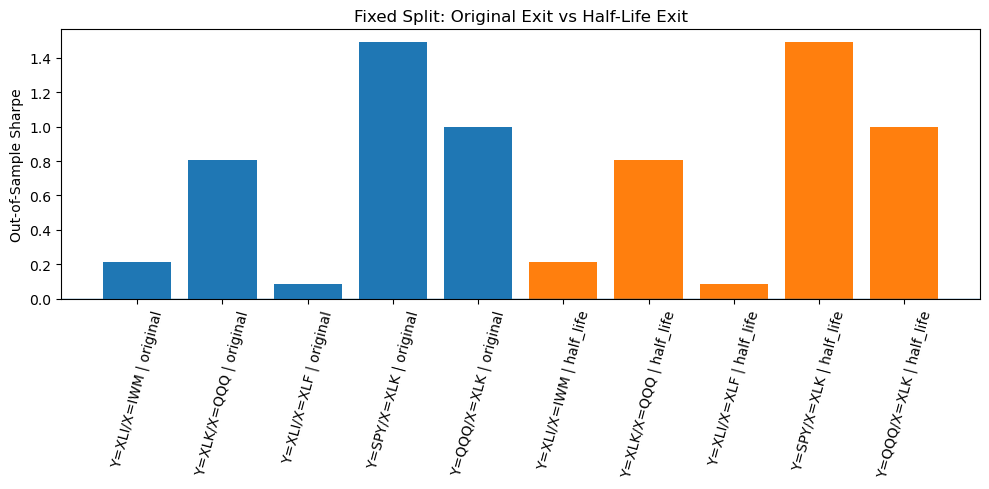

In [37]:
plot_df = fixed_comparison.copy()

plt.figure(figsize=(10, 5))

for exit_rule in plot_df["exit_rule"].unique():
    subset = plot_df[plot_df["exit_rule"] == exit_rule]
    plt.bar(
        subset["pair"] + " | " + exit_rule,
        subset["sharpe_ratio"],
        label=exit_rule,
    )

plt.axhline(0, linewidth=1)
plt.xticks(rotation=75)
plt.ylabel("Out-of-Sample Sharpe")
plt.title("Fixed Split: Original Exit vs Half-Life Exit")
plt.tight_layout()
plt.show()

In [39]:
original_half_life_multiplier = half_life_multiplier

half_life_multiplier = 1.0

fixed_half_life_1x_results = evaluate_selected_pairs(
    prices=prices,
    selected_pairs=fixed_selected_pairs,
    train_start=fixed_train_start,
    train_end=fixed_train_end,
    test_start=fixed_test_start,
    test_end=fixed_test_end,
    use_half_life_exit=True,
)

fixed_half_life_1x_results["exit_rule"] = "half_life_1x"

half_life_multiplier = original_half_life_multiplier

fixed_half_life_1x_results[result_cols].sort_values(
    "sharpe_ratio",
    ascending=False,
).round(4)

,exit_rule,pair,ticker_y,ticker_x,train_correlation,train_sharpe,half_life,max_holding_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_trades,win_rate,avg_holding_days,days_in_market_frac
3,half_life_1x,Y=SPY/X=XLK,SPY,XLK,0.9339,0.2389,37.3860,37,0.0815,0.0401,0.0266,1.4919,-0.0163,9,1.0000,14.4444,0.2410
4,half_life_1x,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.1788,40.2146,40,0.0338,0.0168,0.0180,0.9369,-0.0182,9,0.7778,19.2222,0.3267
1,half_life_1x,Y=XLK/X=QQQ,XLK,QQQ,0.9763,0.3231,34.5490,35,0.0186,0.0093,0.0219,0.4346,-0.0353,9,0.7778,17.1111,0.2888
0,half_life_1x,Y=XLI/X=IWM,XLI,IWM,0.8597,0.6637,46.7652,47,0.0124,0.0062,0.0334,0.2023,-0.0392,8,0.8750,23.7500,0.3625
2,half_life_1x,Y=XLI/X=XLF,XLI,XLF,0.8819,0.2949,53.2147,53,-0.0043,-0.0022,0.0364,-0.0418,-0.0518,8,0.7500,21.1250,0.3486


In [41]:
fixed_comparison_extended = pd.concat(
    [
        fixed_original_results,
        fixed_half_life_1x_results,
        fixed_half_life_results,
    ],
    ignore_index=True,
)

fixed_comparison_extended[
    result_cols
].sort_values(
    ["pair", "exit_rule"]
).round(4)

,exit_rule,pair,ticker_y,ticker_x,train_correlation,train_sharpe,half_life,max_holding_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_trades,win_rate,avg_holding_days,days_in_market_frac
14,half_life,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.1788,40.2146,120,0.0365,0.0181,0.0182,0.9972,-0.0182,9,0.8889,20.7778,0.3546
9,half_life_1x,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.1788,40.2146,40,0.0338,0.0168,0.0180,0.9369,-0.0182,9,0.7778,19.2222,0.3267
4,original,Y=QQQ/X=XLK,QQQ,XLK,0.9763,0.1788,NaN,None,0.0365,0.0181,0.0182,0.9972,-0.0182,9,0.8889,20.7778,0.3546
13,half_life,Y=SPY/X=XLK,SPY,XLK,0.9339,0.2389,37.3860,112,0.0815,0.0401,0.0266,1.4919,-0.0163,9,1.0000,14.4444,0.2410
8,half_life_1x,Y=SPY/X=XLK,SPY,XLK,0.9339,0.2389,37.3860,37,0.0815,0.0401,0.0266,1.4919,-0.0163,9,1.0000,14.4444,0.2410
3,original,Y=SPY/X=XLK,SPY,XLK,0.9339,0.2389,NaN,None,0.0815,0.0401,0.0266,1.4919,-0.0163,9,1.0000,14.4444,0.2410
10,half_life,Y=XLI/X=IWM,XLI,IWM,0.8597,0.6637,46.7652,120,0.0141,0.0071,0.0364,0.2117,-0.0452,7,0.8571,22.7143,0.4502
5,half_life_1x,Y=XLI/X=IWM,XLI,IWM,0.8597,0.6637,46.7652,47,0.0124,0.0062,0.0334,0.2023,-0.0392,8,0.8750,23.7500,0.3625
0,original,Y=XLI/X=IWM,XLI,IWM,0.8597,0.6637,NaN,None,0.0141,0.0071,0.0364,0.2117,-0.0452,7,0.8571,22.7143,0.4502
12,half_life,Y=XLI/X=XLF,XLI,XLF,0.8819,0.2949,53.2147,120,0.0047,0.0024,0.0374,0.0820,-0.0549,8,0.7500,23.8750,0.3924


In [43]:
fixed_summary_extended = (
    fixed_comparison_extended
    .groupby("exit_rule")
    .agg(
        avg_total_return=("total_return", "mean"),
        avg_annualized_return=("annualized_return", "mean"),
        avg_volatility=("annualized_volatility", "mean"),
        avg_sharpe=("sharpe_ratio", "mean"),
        avg_max_drawdown=("max_drawdown", "mean"),
        total_trades=("n_trades", "sum"),
        avg_win_rate=("win_rate", "mean"),
        avg_holding_days=("avg_holding_days", "mean"),
        avg_days_in_market=("days_in_market_frac", "mean"),
    )
)

fixed_summary_extended.round(4)

,avg_total_return,avg_annualized_return,avg_volatility,avg_sharpe,avg_max_drawdown,total_trades,avg_win_rate,avg_holding_days,avg_days_in_market
exit_rule,,,,,,,,,
half_life,0.0347,0.0172,0.0283,0.7179,-0.0319,42,0.8548,20.2734,0.3542
half_life_1x,0.0284,0.0141,0.0273,0.6048,-0.0322,43,0.8361,19.1306,0.3135
original,0.0347,0.0172,0.0283,0.7179,-0.0319,42,0.8548,20.2734,0.3542


## Interpretation

The half-life exit rule did not materially change the results. With the 3x half-life rule, the maximum holding periods were generally above 100 trading days, while the actual average holding periods were much shorter. This means the half-life exist was not binding.

A stricter 1x half-life rule also had limited impact. Where it did change the results, it generally reduced exposure slightly and sometimes worsened performanc. This suggests the original z-score exit rule already closes trades quickly relative to the estimated mean-reversion half-life.

In this setting, the half-life estimate is more useful as a diagnostic than as an active exit rule.